In [1]:
import matplotlib.pyplot as plt

import torch
from torch import Tensor
from torch.utils.data import DataLoader, random_split
from torchvision.datasets.mnist import MNIST
from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from pathlib import Path

IMAGE_SIZE = 28

data_dir = Path('data')
train_dir = data_dir / 'mnist' / 'train'
test_dir = data_dir / 'mnist' / 'test'

transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [4]:
full_train = MNIST(train_dir, transform=transform, train=True)
test_data = MNIST(test_dir, transform=transform, train=False)

RuntimeError: Dataset not found. You can use download=True to download it

In [ ]:
full_train_size = len(full_train)
train_size = int(0.9 * full_train_size)
val_size = full_train_size - train_size

train_data, val_data = random_split(full_train, [train_size, val_size])

In [6]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=64, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=64, num_workers=2, pin_memory=True)

### CNN

In [7]:
import torch.nn as nn
import torch.nn.functional as F

In [8]:
class CNN(nn.Module):
    
    def __init__(self, in_layer=1, out_layer=10):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Conv2d( , 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(12544, 128),
            nn.ReLU(),
            nn.Linear(128, out_layer)
        )

    def forward(self, x):
        x = self.layers(x)
        x = self.fc(x)
        return x

In [10]:
from torch.optim.adam import Adam
from torch.nn import CrossEntropyLoss

EPOCHS = 200

model = CNN()
model.to(device)

loss_metric = CrossEntropyLoss()
optimizer = Adam(model.parameters())

Epoch 1: new best model saved
Epoch 1/200 | Train Loss: 0.0082 | Train Acc: 0.9972 | Val Loss: 0.0534 | Val Acc: 0.9865
Epoch 2/200 | Train Loss: 0.0063 | Train Acc: 0.9978 | Val Loss: 0.0587 | Val Acc: 0.9883
Epoch 3: new best model saved
Epoch 3/200 | Train Loss: 0.0076 | Train Acc: 0.9976 | Val Loss: 0.0472 | Val Acc: 0.9900
Epoch 4/200 | Train Loss: 0.0059 | Train Acc: 0.9983 | Val Loss: 0.0513 | Val Acc: 0.9887
Epoch 5/200 | Train Loss: 0.0027 | Train Acc: 0.9991 | Val Loss: 0.0546 | Val Acc: 0.9883
Epoch 6/200 | Train Loss: 0.0063 | Train Acc: 0.9979 | Val Loss: 0.0546 | Val Acc: 0.9875
Epoch 7/200 | Train Loss: 0.0063 | Train Acc: 0.9979 | Val Loss: 0.0556 | Val Acc: 0.9900
Early stopping triggered


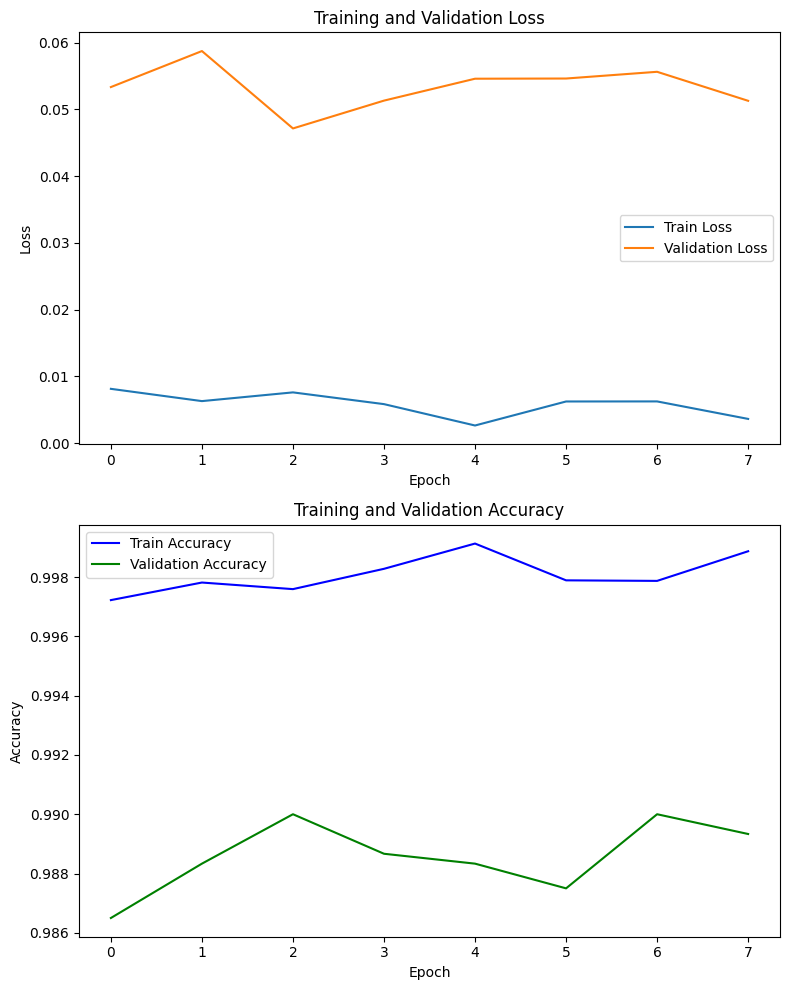

In [14]:
# -----------------------------------------
# settings
# -----------------------------------------
PATIENCE = 5                 # for early stopping
MODEL_PATH = "best_model.pt"
PLOT_PATH = "training_plot.png"

# -----------------------------------------
# tracking lists
# -----------------------------------------
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float("inf")
epochs_no_improve = 0

# -----------------------------------------
# training loop
# -----------------------------------------
for epoch in range(EPOCHS):

    # -------------------- TRAIN --------------------
    model.train()
    batch_train_losses = []
    correct_train = 0
    total_train = 0

    for image, label in train_loader:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        y_pred = model(image)
        loss = loss_metric(y_pred, label)
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())

        preds = y_pred.argmax(dim=1)
        correct_train += (preds == label).sum().item()
        total_train += label.size(0)

    epoch_train_loss = sum(batch_train_losses) / len(batch_train_losses)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # -------------------- VALIDATION --------------------
    model.eval()
    batch_val_losses = []
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for image, label in val_loader:
            image, label = image.to(device), label.to(device)
            y_pred = model(image)
            loss = loss_metric(y_pred, label)
            batch_val_losses.append(loss.item())

            preds = y_pred.argmax(dim=1)
            correct_val += (preds == label).sum().item()
            total_val += label.size(0)

    epoch_val_loss = sum(batch_val_losses) / len(batch_val_losses)
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    # -------------------- EARLY STOPPING + SAVE BEST --------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"Epoch {epoch+1}: new best model saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered")
            break

    # -------------------- LOGGING --------------------
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

# -----------------------------------------
# plot after training
# -----------------------------------------
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10))

# Loss plot
ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()

# Accuracy plot
ax2.plot(train_accs, label="Train Accuracy", color="blue")
ax2.plot(val_accs, label="Validation Accuracy", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig(PLOT_PATH)  # save figure
plt.show()

In [ ]:
# model.train()
# train_losses = []
# for epoch in range(EPOCHS):
#     for i, (image, label) in enumerate(train_loader):
#         optimizer.zero_grad()
#         y_pred = model(image)
#         train_loss = loss_metric(y_pred, label)
#         train_losses.append(loss.item())
#         train_loss.backward()
#         optimizer.step()

#     # validation
#     model.eval()
#     val_losses = []
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for image, label in val_loader:
#             y_pred = model(image)
#             loss = loss_metric(y_pred, label)
#             val_losses.append(loss.item())

#             # accuracy
#             preds = y_pred.argmax(dim=1)
#             correct += (preds == label).sum().item()
#             total += label.size(0)

#     val_accuracy = correct / total

#     print(
#         f"Epoch {epoch+1}/{EPOCHS} | "
#         f"Train loss: {sum(train_losses)/len(train_losses):.4f} | "
#         f"Val loss: {sum(val_losses)/len(val_losses):.4f} | "
#         f"Val acc: {val_accuracy:.4f}"
#     )

In [53]:
model.eval()

CNN(
  (layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [88]:
img_path = Path('test_img.jpg')

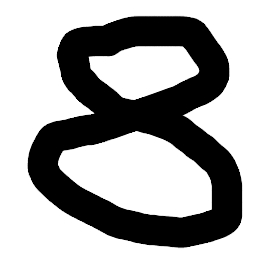

In [91]:
img = Image.open(img_path).convert('L')  # convert to grayscale immediately
img

In [92]:
from PIL import Image
from pathlib import Path
import torchvision.transforms as transforms
import torch

img_path = Path('test_img.jpg')
img = Image.open(img_path).convert('L')  # convert to grayscale immediately

transform = transforms.Compose([
    transforms.Resize((28, 28)),   # MNIST size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

img_tensor = transform(img).unsqueeze(0).to(device)  # (1,1,28,28)

model.eval()
with torch.no_grad():
    y_pred = model(img_tensor)
    pred_class = y_pred.argmax(dim=1).item()

print("Predicted class:", pred_class)


Predicted class: 5


In [47]:
transform = transforms.ToTensor()]
)

In [48]:
with torch.no_grad():
    y_pred = model(transform(img))
    y_pred

RuntimeError: Given groups=1, weight of size [32, 1, 3, 3], expected input[1, 3, 28, 28] to have 1 channels, but got 3 channels instead